# Ordinary Differential Equations: Boundary Value Problems

## Boundary Value Problems

### Shooting Methods

**Example.** A ball was thrown up vertically at an initial position $y(t=0)=0$. The initial velocity is **unknown**. But we know that the ball lands back to $y = 0$ at $t = 10$ seconds. Without considering air friction, solve numerically $y(t)$ in the range $0\le t \le 10$.

**Sol:** The equation of motion from Newton's 2nd law is $\frac{d^2y(t)}{dt^2} = -g$, where $g= 9.81 m/s^2$. The second-order ODE can be converted to two 1st-order ODEs:

$\frac{dy(t)}{dt}\equiv v(t)$, with $y(0)=0$;

$\frac{dv(t)}{dt} = -g$, with $v(0)= v_0$ (unknown).

One may solve the above simultaneous equations with RK4 (with global error $\sim O(h^4)$).

If we use central differences (with global error $\sim O(h^2)$), the above equations become:

$y_{i+1} = y_{i-1} + 2h\cdot v_i$, $i = 1,2,3,..., n-2$,

$v_{i+1} = v_{i-1} - 2h\cdot g$, $i = 1,2,3,..., n-2$.

We will need to know $y(t=0) \equiv y_0$ and $y(t=h) = y_1$, as well as $v(t=0)=v_0$ and $v(t=h)=v_1$ to proceed.

Once $y_0$ and $v_0$ are specified, $y_1$ and $v_1$ can be obtained e.g. via one-step Forward Euler method (with local error $\sim O(h^2)$).

We will treat $v_0$ as a shooting parameter, such that the final solution of $y(t)$ satisfies the boundary condition $y(t=10)=0$.

In [1]:
# Import numpy and matplotlib for scientific calculation/visualization:
import numpy as np
import matplotlib.pyplot as plt

Final time position y(t)= -90.50000000000014


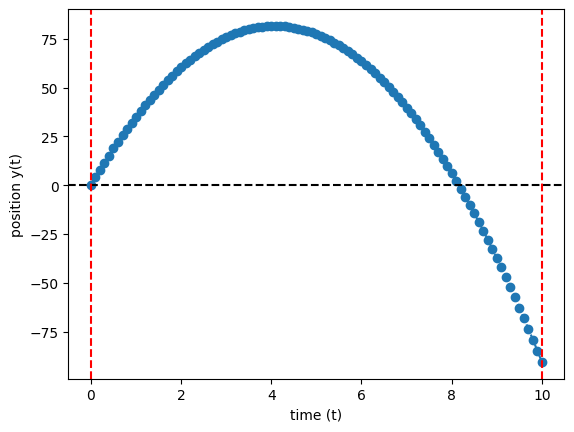

In [2]:
g = 9.81 #acceleration constant.

a = 0.0  #initial time
b = 10.0 #final time
n = 101 #grid points on the time t-axis
h = (b-a)/(n-1) #finite-difference step size

v0 = 40 #shooting parameter
# We know the exact solution should be v0 = 5*g = 49.05 (m/s).

t = np.linspace(a,b,n)

# We need to know y0, y1, as well as v0, v1:

y=np.zeros(n)
y[0] = 0
y[1] = y[0] + h*v0 #Forward Euler, O(h^2) local error.

v=np.zeros(n)
v[0] = v0
v[1] = v[0] -h*g #Forward Euler, O(h^2) local error.

# Central Differences, O(h^2) global error:
for i in range(1,n-1):
    y[i+1]=y[i-1] + 2*h*v[i]
    v[i+1]=v[i-1] -2*h*g
    
plt.plot(t, y,'--o')
plt.axhline(y=0, c='k', ls='--')

plt.axvline(x=0, c='r', ls='--')
plt.axvline(x=10, c='r', ls='--')

ylabel=plt.ylabel('position y(t)')
xlabel=plt.xlabel('time (t)')

print('Final time position y(t)=',y[-1])

In [3]:
# Bisection shooting:

# Copy/paste from the above cell:
def FinalHeight(v0):
    g = 9.81 #acceleration constant.

    a = 0.0  #initial time
    b = 10.0 #final time
    n = 101 #grid points on the time t-axis
    h = (b-a)/(n-1) #finite-difference step size

    t = np.linspace(a,b,n)

    # We need to know y0, y1, as well as v0, v1:
    y=np.zeros(n)
    y[0] = 0
    y[1] = y[0] + h*v0 #Forward Euler, O(h^2) local error.

    v=np.zeros(n)
    v[0] = v0
    v[1] = v[0] -h*g #Forward Euler, O(h^2) local error.

    # Central Differences, O(h^2) global error.
    for i in range(1,n-1):
        y[i+1]=y[i-1] + 2*h*v[i]
        v[i+1]=v[i-1] -2*h*g
    
    return y[-1]

#Binary search:
# need two shooting parameters to bracket the boundary value.
# which in this case is y = 0 at the last time step.
v1=1
print('Final height =', FinalHeight(v1),', for v0 =', v1)
v2=100
print('Final height =', FinalHeight(v2), ', for v0 =', v2)

h1 = FinalHeight(v1)
h2 = FinalHeight(v2)

# y[-1] should be 0 + some small tolerance (target)
target = 1e-8 # target accuracy for binary search

while abs(h2-h1) > target:
    vb = (v1+v2)/2
    hb = FinalHeight(vb)
    if h1*hb > 0:
        h1=hb
        v1=vb
    else:
        h2=hb
        v2=vb

print('Final height =', hb, ', for v0 =', vb)

Final height = -480.50000000000034 , for v0 = 1
Final height = 509.4999999999993 , for v0 = 100
Final height = 5.381668444215393e-10 , for v0 = 49.05000000005384


**Exercise:** Solve the above problem with RK4 and bisection (binary) shooting.

In [4]:
# Your code starts here:

**Exercise:** Solve the above problem with central differences and secant shooting.

In [5]:
# Your code starts here:

### Matrix Method

**Example.** Solve the following boundary value problem:

$y''(x) = -5y'(x) +5x$, with the boundary values $y(0)=1$ and $y(1)=0$.

finite difference step size h = 0.02


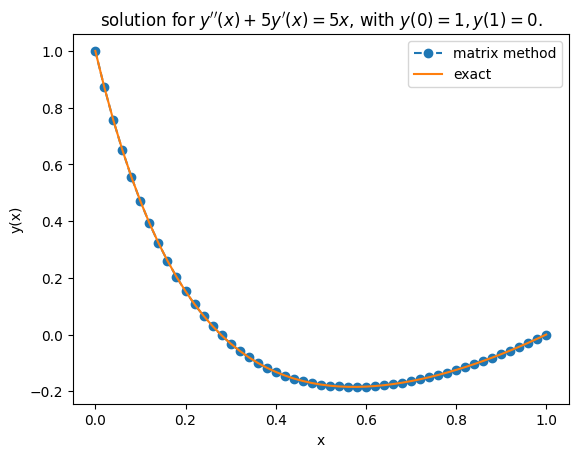

In [7]:
# Matrix or Finite-Difference Approach:
# Using central differences, the global error is between ~O(h) to O(h^2).

# Set the x-grid:
n = 51
a = 0
b = 1
h = (b-a)/(n-1)

print('finite difference step size h =',h)

x = np.linspace(a,b,n)

# Set the A matrix:
A = np.zeros((n,n))

alpha = 1-2.5*h
beta = 1+2.5*h

for i in range(1,n-1):
    A[i,i-1] = alpha
    A[i,i] = -2
    A[i,i+1] = beta
    
A[0,0] = 1 #Always
A[n-1,n-1] = 1 #Always

# Set the v vector:
v = np.zeros(n)
v = 5*h**2*x

v[0] = 1 #Boundary value at x0
v[n-1] = 0 #Boundary value at x_{n-1}

# Matrix inversion & multiplication to obtain solution
# for the linear equation: Ay = v => y = A^-1 v.
Ainv = np.linalg.inv(A)
y = np.matmul(Ainv, v)

plt.plot(x,y,'--o', label='matrix method')

from numpy import e
yexact = -(5*x**2+e**5*(-5*x**2+2*x+3)-2*x-13*e**(5-5*x)+10)/10/(e**5-1)
plt.plot(x, yexact, label='exact')

plt.legend()
plt.xlabel('x')
plt.ylabel('y(x)')
title = plt.title("solution for $y''(x)+5y'(x)= 5x$, with $y(0)=1, y(1)=0$.")

## Eigenvalue Problems

Here we consider the 1D Schroginer equation:

$-\frac{\hbar^2}{2m}\psi''(x) + V(x)\psi(x) = E\psi(x)$.

There exist non-zero solutions for $\psi(x)$ only for certain values of $E$ (called the eigenvalues). One can treat $E$ as a shooting parater and solve the ODE to satisfy the required boundary conditions $\psi(a)$ and $\psi(b)$ (which for a finite $V$, $\psi$ are typically zero when the bounds $a$ and $b$ $\rightarrow \pm\infty$).

**Example.** Solve the 1D infinite potential well problem, where $V(x) = 0$ for $0 \le x \le L$, and $V(x)=\infty$ elsewhere. The boundary conditions are $\psi(x=0)=0$ and $\psi(x=L)=0$. For simplicity, we use the units that $\hbar^2/2m \equiv 1$, and $L \equiv 1$.

**Sol:** We once again convert the 2nd-order ODE to two 1st-order ODEs:

$\frac{d\psi(x)}{dx} \equiv \phi(x)$,

$\frac{d \phi(x)}{dx} = (V(x)-E)\psi(x)$.

We use the initial conditions $\psi(x=0)=0$ and $\phi(x=0) = \phi_0$ (an arbitrary non-zero number; it can be determined uniquely later by the normalization condition). Here, $E$ is a shooting parater chosen to satisfy the second boundary condition $\psi(x=L)=0$.

### Shooting Methods

-1.3421487608440827e-05


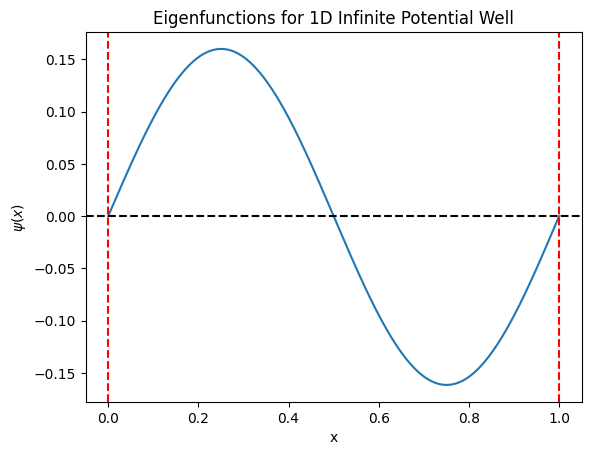

In [9]:
a=0
b=1
n = 1001
h = (b-a)/(n-1)

x = np.linspace(a,b,n)

psi = np.zeros(n)
psi[0] = 0

phi = np.zeros(n)
phi[0] = 1 
#or any other non-zero value you like;
#it can be uniquely determined later from wavefunction renormalization.

#Exact ground state energy
#E = 1.0*np.pi**2

#Exact 1st excited state energy
E = 4.0*np.pi**2

#For accuracy, one should use O(h^2) or O(h^4) methods.
#For simplicity, here we just use Forward Euler, with O(h) global error:
for ii in range(0,n-1):
    psi[ii+1] = psi[ii] + h*phi[ii]
    phi[ii+1] = phi[ii] + h*(-E)*psi[ii] # V is zero inside the well.

plt.plot(x,psi,'-')

plt.xlabel('x')
plt.ylabel(r'$\psi(x)$')
plt.title('Eigenfunctions for 1D Infinite Potential Well')

plt.axhline(y=0, c = 'k',linestyle='--')
plt.axvline(x=a, c = 'r',linestyle='--')
plt.axvline(x=b, c='r', linestyle='--')

# Check how well the second boundary value is satisfied:
print(psi[-1])

In [10]:
normalization = np.trapezoid(phi**2,x)

print(normalization)

# We can use the above result and let
# phi[0] = phi[0]/sqrt(normalization),
# to make the resulting wavefunction psi(x) normalized.

0.5099987642768229


**Exercise:**
1. Shoot for different excited states, by tracking the number of nodes in the energy eigenfuctions.
2. Solve the above problem with more accurate $O(h^2)$ or $O(h^4)$ methods.

In [11]:
# Your code starts here:

### Matrix Method

In [12]:
# Define the potential V(x):
# It takes a scalar value as input,
# and returns a scalar value as well.

def vofx(xi):
    #1D box for x between [0,1]:
    if (xi <= 1.0 and xi >= 0.0):
        vi = 0.0
    else:
        vi = 1.0e9 #some very big value.
    return vi

In [15]:
vofx(1.1)

1000000000.0

In [17]:
# Define the x-grid:
a = 0
b = 1
n = 101
dx = (b-a)/(n-1)

x = np.linspace(a,b,n)

# Define the matrix:
# For simplicity, let hbar^2/2m=1:
# k = hbar**2/2/m/(dx**2)
k = 1/(dx**2)

#Note about the matrix dimension:
Hmatrix = np.zeros((n-2,n-2))

Hmatrix[0][0] = 2*k + vofx(x[1])
Hmatrix[0][1] = -k

Hmatrix[-1][-2]= -k
Hmatrix[-1][-1]= 2*k + vofx(x[n-2])

for ii in range(1,n-3):
    Hmatrix[ii][ii] = 2*k + vofx(x[ii+1])
    Hmatrix[ii][ii+1] = -k
    Hmatrix[ii][ii-1] = -k
    
#Solve the energy eigenvalue problem: H*Psi = E*Psi.
#np.eigh returns eigenvalues and eigenvectors of a Hermitian matrix.
val, vec = np.linalg.eigh(Hmatrix)

#Note about matrix diagonalization time!!!
#Can try sparse matrix diagonalization if the matrix size is too large.

#In our units, the exact three lowest energies are
#E0 = pi^2 = 9.869604401089358; 
#E1 = 4E0 = 39.47841760435743;
#E2 = 9E0 = 88.82643960980423

#Print the eigenvalues:
print('Eigenvalues:', val[0:3])
print(vec)

Eigenvalues: [ 9.86879269 39.46543143 88.76070794]
[[ 0.00444215 -0.00887992 -0.01330893 ...  0.01330893 -0.00887992
  -0.00444215]
 [ 0.00887992 -0.0177248  -0.02649972 ... -0.02649972  0.0177248
   0.00887992]
 [ 0.01330893 -0.02649972 -0.0394553  ...  0.0394553  -0.02649972
  -0.01330893]
 ...
 [ 0.01330893  0.02649972 -0.0394553  ...  0.0394553   0.02649972
  -0.01330893]
 [ 0.00887992  0.0177248  -0.02649972 ... -0.02649972 -0.0177248
   0.00887992]
 [ 0.00444215  0.00887992 -0.01330893 ...  0.01330893  0.00887992
  -0.00444215]]


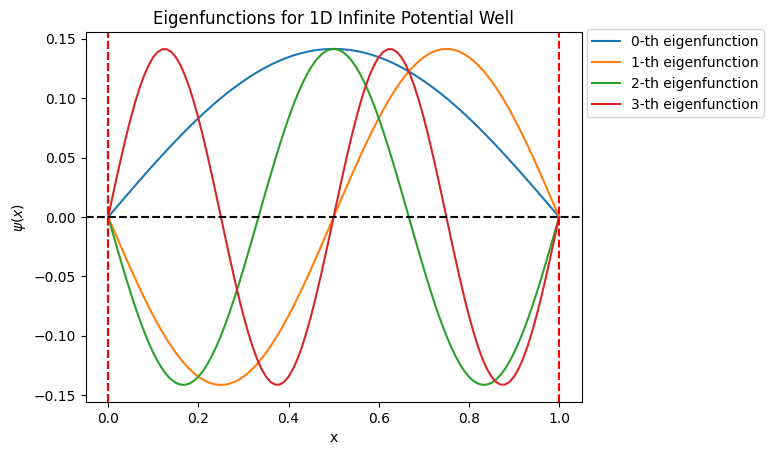

In [18]:
#Plot the eigenfunctions:

plt.axvline(x=0, c='k',ls='--')

psi = np.zeros(n)
#Boundary values (exactly satisfied):
psi[0] = 0
psi[-1] = 0

for ii in range(0,4):

    #Note: The column eigenvectors[:,ii] is the eigenvector 
    #corresponding to the eigenvalue eigenvalues[i].
    psi[1:-1] = vec[:, ii]
    plt.plot(x,psi, label = str(ii)+'-th eigenfunction')

plt.legend(loc=(1.01,0.77))

plt.xlabel('x')
plt.ylabel(r'$\psi(x)$')
plt.title('Eigenfunctions for 1D Infinite Potential Well')

plt.axhline(y=0, c = 'k',linestyle='--')
plt.axvline(x=a, c = 'r',linestyle='--')
plt.axvline(x=b, c='r', linestyle='--')

In [19]:
# Note that the eigenfunctions are orthogonal:

print(np.dot(vec[:,0],vec[:,1]))
print(np.dot(vec[:,0],vec[:,2]))
print(np.dot(vec[:,1],vec[:,2]))

4.246277808539478e-16
2.1787042656096212e-16
-4.591054099389869e-16


In [20]:
# Note about the normalization!

psi=np.zeros(n)
#Boundary values
psi[0] = 0
psi[-1] = 0

psi[1:-1] = vec[:,0]
norm2 = np.trapezoid(psi**2, x, dx)
print(norm2)
#Note: The eigenfunction retured by numpy.eigh is 
#normalized by np.dot(psi,psi)=1, which is not what we want!

#One can then obtained a properly normalized psi by
psi=psi/np.sqrt(norm2)
print(np.trapezoid(psi**2, x, dx))

0.010000000000000004
0.9999999999999998


**Exercise:**
Solve the first three energy eigen-values and eigen-functions for a particle in a 1D harmonic potential $V(x) = \frac{m\omega_0^2 x^2}{2}$. Compare (plot) the eigenvalues (eigenfunctions) against the exact solutions. For simplicity, use the units $\hbar \equiv 1$, $m\equiv 1$, and $\omega_0 \equiv 1$.

In [21]:
# Your code starts here: